<a href="https://colab.research.google.com/github/aricore87/aphelion/blob/main/Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Task 5
1) The brightness of a circle of radius reduces from the centre towards the edge as B(r)= B0*exp(-r/R).
Calculate the total brightness of circle.
You may consider circular disc made of n number of concentric circles and calculate the total brightness.
2) Consider another black circle of same radius R sliding over the above circle. Hence determine the brightness exposed as function of distance between two circles.
3) Plot the total brightness as the dark circle moves over bright circle from one end to another.

1) Total Brightness (Concentric Rings Approximation): 1.660276
   Total Brightness (Analytical Solution):          1.660276


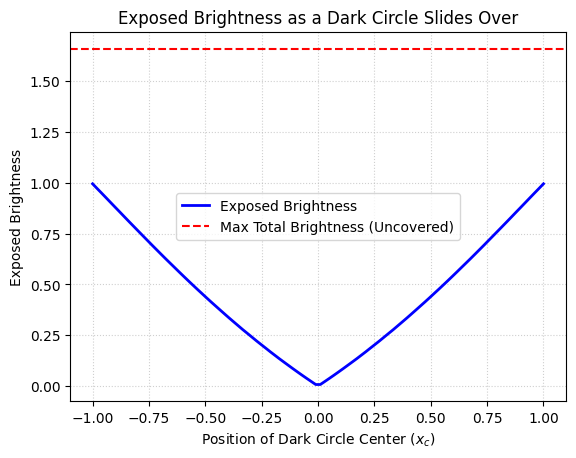

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define constants
B0 = 1.0  # Peak central brightness
R = 1.0   # Radius of both circles



# Concentric rings approach (Numerical Integration)
def total_brightness_concentric(n_rings=1000):
    dr = R / n_rings
    total_B = 0.0
    for i in range(n_rings):
        r = (i + 0.5) * dr  # Mid-point of each concentric ring
        area_ring = 2 * np.pi * r * dr
        total_B += B0 * np.exp(-r / R) * area_ring
    return total_B


I_total_analytical = 2 * np.pi * B0 * (R**2) * (1 - 2 / np.e)

print(f"1) Total Brightness (Concentric Rings Approximation): {total_brightness_concentric():.6f}")
print(f"   Total Brightness (Analytical Solution):          {I_total_analytical:.6f}")



# 2) Calculate Exposed Brightness Function

def exposed_brightness(d, num_r=300, num_theta=300):

    dr = R / num_r
    dtheta = 2 * np.pi / num_theta

    # Create polar grid arrays
    r_vals = np.linspace(dr/2, R - dr/2, num_r)
    theta_vals = np.linspace(dtheta/2, 2*np.pi - dtheta/2, num_theta)
    R_mesh, Theta_mesh = np.meshgrid(r_vals, theta_vals)

    # Distance squared from any point on the bright circle to the dark circle center
    dist_sq = R_mesh**2 - 2 * R_mesh * d * np.cos(Theta_mesh) + d**2

    # Mask to keep only the exposed region (where distance to dark center > R)
    exposed_mask = dist_sq > R**2

    # Calculate brightness and differential area element (dA = r * dr * dtheta)
    brightness = B0 * np.exp(-R_mesh / R)
    area_element = R_mesh * dr * dtheta

    # Integrate over the exposed region
    exposed_B = np.sum(brightness[exposed_mask] * area_element[exposed_mask])
    return exposed_B



# 3) Plot the Total Brightness Over Motion


# Center position of the dark circle moving from -2R to 2R
x_center_vals = np.linspace(-R,  R, 100)
exposed_vals = [exposed_brightness(abs(xc)) for xc in x_center_vals]

# Generate and save the plot
plt.plot(x_center_vals, exposed_vals, 'b-', linewidth=2, label='Exposed Brightness')
plt.axhline(y=I_total_analytical, color='r', linestyle='--', label='Max Total Brightness (Uncovered)')
plt.xlabel('Position of Dark Circle Center ($x_c$)')
plt.ylabel('Exposed Brightness')
plt.title('Exposed Brightness as a Dark Circle Slides Over')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
